# Replicating Jackson et al. 2020 (Nature) - Single-Cell Pathology Landscape of Breast Cancer

This notebook reproduces the **core methodology** of:

> Jackson HW, Fischer JR, Zanotelli VRT, et al.
> *"The single-cell pathology landscape of breast cancer"*  
> **Nature** 578, 615-620 (2020)

### Key analyses reproduced in principle:
1. **Multi-marker cell phenotyping** via a PhenoGraph demo on 10,000 sampled Basel cells
2. **Validation** against the paper's pre-computed Basel cluster labels (`PG_final_k20.csv`)
3. **t-SNE visualization** of the cellular landscape using the paper's saved Basel t-SNE coordinates
4. **Phenotype abundance** per tissue core/patient record with Kaplan-Meier survival examples
5. **Cox proportional hazards** modeling for Basel phenotype abundance, including a multivariable model
6. **Spatial neighborhood analysis** using released X/Y cell coordinates for sampled Basel and Zurich cores
7. **Summary validation table** describing which paper-level analysis ideas were reproduced, simplified, or skipped

> **Note:** This is a downsampled Colab reproduction, not a full-scale rerun of the paper. The notebook samples 100,000 complete cells per cohort, uses released paper labels/coordinates where needed, runs survival analysis for Basel, and uses Zurich for phenotype/spatial validation because usable merged Zurich survival rows were not available. Independent PhenoGraph clustering is demonstrated on a 10,000-cell Basel subsample.

In [5]:
options(
  repos = c(CRAN = "https://packagemanager.posit.co/cran/__linux__/jammy/latest"),
  timeout = 1200
)

cran_pkgs <- c(
  "data.table",
  "dplyr",
  "ggplot2",
  "survival",
  "survminer",
  "Rtsne",
  "gridExtra",
  "RANN"
)

for (pkg in cran_pkgs) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    message("Installing CRAN package: ", pkg)
    install.packages(pkg, dependencies = TRUE)
  }
}

if (!requireNamespace("Rphenograph", quietly = TRUE)) {
  if (!requireNamespace("remotes", quietly = TRUE)) {
    message("Installing remotes...")
    install.packages("remotes", dependencies = TRUE)
  }

  message("Installing Rphenograph from GitHub...")
  remotes::install_github(
    "JinmiaoChenLab/Rphenograph",
    dependencies = TRUE,
    upgrade = "never"
  )
}

required_pkgs <- c(cran_pkgs, "Rphenograph")

missing_pkgs <- required_pkgs[
  !vapply(required_pkgs, requireNamespace, logical(1), quietly = TRUE)
]

if (length(missing_pkgs) > 0) {
  stop(
    "Failed to install/load: ",
    paste(missing_pkgs, collapse = ", "),
    "\nRestart the Colab runtime and rerun Cell 1."
  )
}

invisible(lapply(required_pkgs, library, character.only = TRUE))

message("All dependencies loaded successfully.")
set.seed(42L)

Installing Rphenograph from GitHub...


Installing 1 packages: igraph

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpbUnJfc/remotesdcb3376a401/JinmiaoChenLab-Rphenograph-0298487/DESCRIPTION’ ... OK
* preparing ‘Rphenograph’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘Rphenograph_0.99.1.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


All dependencies loaded successfully.



In [2]:
CONFIG <- list(
  COHORT        = "both",

  URL_ZENODO    = "https://zenodo.org/records/3518284/files/SingleCell_and_Metadata.zip?download=1",
  URL_LOCS      = "https://zenodo.org/record/4607374/files/singlecell_locations.zip?download=1",

  FILE_ZIP      = "SingleCell_and_Metadata.zip",
  FILE_ZIP_LOC  = "singlecell_locations.zip",
  FILE_SUBSET   = "subset_SC_dat.csv",
  FILE_METADATA = "Dataset_SC/Data_publication/BaselTMA/Basel_PatientMetadata.csv",
  FILE_SC_RAW   = "Dataset_SC/Data_publication/BaselTMA/SC_dat.csv",
  FILE_LOCS     = "Dataset_SC/Spatial_Locations/Basel_SC_locations.csv",
  FILE_PG       = "Dataset_SC/Data_publication/BaselTMA/PG_final_k20.csv",
  FILE_TSNE     = "Dataset_SC/Data_publication/BaselTMA/tsne_final.csv",
  FILE_DIST     = "Dataset_SC/Data_publication/BaselTMA/SC_Distances.csv",

  FILE_SUBSET_ZURI = "subset_SC_dat_zuri.csv",
  FILE_METADATA_ZURI = "Dataset_SC/Data_publication/ZurichTMA/Zuri_PatientMetadata.csv",
  FILE_SC_RAW_ZURI   = "Dataset_SC/Data_publication/ZurichTMA/SC_dat.csv",
  FILE_PG_ZURI       = "Dataset_SC/Data_publication/ZurichTMA/PG_zurich.csv",
  FILE_LOCS_ZURI     = "Dataset_SC/Spatial_Locations/Zuri_SC_locations.csv",

  DOWNSAMPLE    = 100000L,
  SEED          = 42L
)
message("Configuration loaded.")

Configuration loaded.



In [13]:
make_cell_subset <- function(raw_file, subset_file, n_cells, label) {
  ids_file <- paste0("sampled_ids_", label, ".txt")

  if (!file.exists(raw_file)) {
    stop("Raw file missing: ", raw_file,
         "\nNeed to re-download/extract SingleCell_and_Metadata.zip first.")
  }

  message("Sampling complete cells for ", label, "...")
  cmd_ids <- sprintf(
    "awk -F, 'NR==1{for(i=1;i<=NF;i++) if($i==\"id\") idcol=i; next} !seen[$idcol]++ {print $idcol}' %s | shuf -n %d > %s",
    shQuote(raw_file),
    as.integer(n_cells),
    shQuote(ids_file)
  )
  status <- system(cmd_ids)
  if (status != 0) stop("Failed to sample cell IDs for ", label)

  message("Writing complete long-format subset for ", label, "...")
  cmd_subset <- sprintf(
    "awk -F, 'NR==FNR{keep[$1]=1; next} FNR==1{print; for(i=1;i<=NF;i++) if($i==\"id\") idcol=i; next} ($idcol in keep)' %s %s > %s",
    shQuote(ids_file),
    shQuote(raw_file),
    shQuote(subset_file)
  )
  status <- system(cmd_subset)
  if (status != 0) stop("Failed to write subset for ", label)

  file.remove(ids_file)
  message("Created ", subset_file)
}

subset_is_bad <- function(subset_file) {
  if (!file.exists(subset_file)) return(TRUE)

  x <- fread(subset_file, select = "id", nrows = 200000)
  rows_per_cell <- nrow(x) / data.table::uniqueN(x$id)

  message("Existing subset check: approx rows per cell = ", round(rows_per_cell, 2))

  rows_per_cell < 10
}

if (!file.exists(CONFIG$FILE_SC_RAW)) {
  message("Raw SC_dat.csv not found. Downloading main dataset.")
  system(paste("wget -q -O", CONFIG$FILE_ZIP, shQuote(CONFIG$URL_ZENODO)))

  message("Extracting main dataset...")
  system(paste("unzip -q", CONFIG$FILE_ZIP, "-d Dataset_SC"))

  if (file.exists(CONFIG$FILE_ZIP)) file.remove(CONFIG$FILE_ZIP)
}

if (subset_is_bad(CONFIG$FILE_SUBSET)) {
  message("Rebuilding Basel subset using complete cell IDs...")
  make_cell_subset(
    raw_file = CONFIG$FILE_SC_RAW,
    subset_file = CONFIG$FILE_SUBSET,
    n_cells = CONFIG$DOWNSAMPLE,
    label = "basel"
  )
} else {
  message("Basel subset already looks cell-complete. Keeping it.")
}

loc_candidates <- c(
  CONFIG$FILE_LOCS,
  "Dataset_SC/Basel_SC_locations.csv",
  "Basel_SC_locations.csv"
)

if (!any(file.exists(loc_candidates))) {
  message("Downloading spatial coordinates...")
  download.file(CONFIG$URL_LOCS, CONFIG$FILE_ZIP_LOC, mode = "wb", method = "libcurl")
  unzip(CONFIG$FILE_ZIP_LOC, exdir = "Dataset_SC")
  file.remove(CONFIG$FILE_ZIP_LOC)
} else {
  message("Spatial coordinates already found.")
}

if (CONFIG$COHORT %in% c("Zurich", "both")) {
  if (file.exists(CONFIG$FILE_SC_RAW_ZURI)) {
    if (subset_is_bad(CONFIG$FILE_SUBSET_ZURI)) {
      message("Rebuilding Zurich subset using complete cell IDs...")
      make_cell_subset(
        raw_file = CONFIG$FILE_SC_RAW_ZURI,
        subset_file = CONFIG$FILE_SUBSET_ZURI,
        n_cells = CONFIG$DOWNSAMPLE,
        label = "zurich"
      )
    } else {
      message("Zurich subset already looks cell-complete. Keeping it.")
    }
  } else {
    message("Zurich raw file not found yet. Skipping Zurich subset for now.")
  }
}

message("All data ready for analysis.")

Raw SC_dat.csv not found. Downloading main dataset again...

Extracting main dataset...



[1] TRUE

Existing subset check: approx rows per cell = 1.06

Rebuilding Basel subset using complete cell IDs...

Sampling complete cells for basel...

Writing complete long-format subset for basel...

Created subset_SC_dat.csv

Spatial coordinates already found.

Existing subset check: approx rows per cell = 1.12

Rebuilding Zurich subset using complete cell IDs...

Sampling complete cells for zurich...

Writing complete long-format subset for zurich...

Created subset_SC_dat_zuri.csv

All data ready for analysis.



In [15]:
message("Loading Metadata and Single-Cell Subset...")

find_existing_file <- function(candidates, pattern = NULL, label = "file") {
  candidates <- unique(candidates[!is.na(candidates) & nzchar(candidates)])

  for (p in candidates) {
    if (file.exists(p)) return(p)
  }

  if (!is.null(pattern)) {
    hits <- list.files(".", pattern = pattern, recursive = TRUE, full.names = TRUE)
    if (length(hits) > 0) return(hits[1])
  }

  stop("Could not find ", label, ". Tried: ", paste(candidates, collapse = ", "))
}

metadata_file <- find_existing_file(
  c(
    CONFIG$FILE_METADATA,
    "Dataset_SC/Data_publication/BaselTMA/Basel_PatientMetadata.csv",
    "Data_publication/BaselTMA/Basel_PatientMetadata.csv"
  ),
  pattern = "^Basel_PatientMetadata\\.csv$",
  label = "Basel patient metadata"
)

subset_file <- find_existing_file(
  c(CONFIG$FILE_SUBSET, CONFIG$FILE_SC_RAW),
  pattern = "^subset_SC_dat\\.csv$|^SC_dat\\.csv$",
  label = "Basel single-cell data"
)

loc_file <- find_existing_file(
  c(
    CONFIG$FILE_LOCS,
    "Dataset_SC/Basel_SC_locations.csv",
    "Basel_SC_locations.csv",
    "Data_publication/Basel_SC_locations.csv"
  ),
  pattern = "^Basel_SC_locations\\.csv$",
  label = "Basel spatial locations"
)

pg_file <- find_existing_file(
  c(
    CONFIG$FILE_PG,
    "Dataset_SC/Data_publication/BaselTMA/PG_final_k20.csv",
    "Data_publication/BaselTMA/PG_final_k20.csv",
    "Dataset_SC/Cluster_labels/PG_basel.csv",
    "Cluster_labels/PG_basel.csv"
  ),
  pattern = "^PG_final_k20\\.csv$|^PG_basel\\.csv$",
  label = "Basel PhenoGraph labels"
)

tsne_file <- find_existing_file(
  c(
    CONFIG$FILE_TSNE,
    "Dataset_SC/Data_publication/BaselTMA/tsne_final.csv",
    "Data_publication/BaselTMA/tsne_final.csv"
  ),
  pattern = "^tsne_final\\.csv$",
  label = "Basel t-SNE coordinates"
)

cat("  Metadata file:", metadata_file, "\n")
cat("  Single-cell file:", subset_file, "\n")
cat("  Locations file:", loc_file, "\n")
cat("  PhenoGraph file:", pg_file, "\n")
cat("  t-SNE file:", tsne_file, "\n")

meta_data <- fread(metadata_file)
cat("  Patients:", nrow(meta_data), "\n")

message("Loading single-cell data subset...")
sc_subset <- fread(subset_file)
cat("  Cells:", nrow(sc_subset), "\n")

message("Casting long -> wide...")
sc_wide <- dcast(sc_subset, core + CellId + id ~ channel, value.var = "mc_counts")
cat("  Wide dim:", nrow(sc_wide), "x", ncol(sc_wide), "\n")

cell_key <- unique(sc_wide[, .(id, core, CellId)])

message("Loading spatial locations...")
locations_raw <- fread(loc_file)
cat("  Raw locations:", nrow(locations_raw), "\n")
cat("  Location columns:", paste(names(locations_raw), collapse = ", "), "\n")

if ("id" %in% names(locations_raw)) {
  loc_value_cols <- setdiff(names(locations_raw), c("id", "core", "CellId"))
  locations <- merge(
    cell_key,
    locations_raw[, c("id", loc_value_cols), with = FALSE],
    by = "id",
    all.x = FALSE,
    all.y = FALSE
  )
  locations[, id := NULL]
} else if (all(c("core", "CellId") %in% names(locations_raw))) {
  loc_value_cols <- setdiff(names(locations_raw), c("core", "CellId"))
  locations <- locations_raw[, c("core", "CellId", loc_value_cols), with = FALSE]
} else {
  stop(
    "Cannot merge locations. Expected either 'id' or both 'core' and 'CellId'. Columns found: ",
    paste(names(locations_raw), collapse = ", ")
  )
}

cat("  Locations matched to subset:", nrow(locations), "\n")
cat("  Clean location columns:", paste(names(locations), collapse = ", "), "\n")

message("Loading pre-computed PhenoGraph clusters...")
pg_raw <- fread(pg_file)
cat("  Raw PG rows:", nrow(pg_raw), "\n")
cat("  Raw PG columns:", paste(names(pg_raw), collapse = ", "), "\n")

pg_key_cols <- intersect(c("id", "core", "CellId"), names(pg_raw))
pg_value_cols <- setdiff(names(pg_raw), pg_key_cols)

if (length(pg_value_cols) < 1) {
  stop("Could not identify cluster-label column in PG file.")
}

preferred_pg <- grep("PhenoGraph|cluster|meta", pg_value_cols, ignore.case = TRUE, value = TRUE)
pg_value_col <- if (length(preferred_pg) > 0) preferred_pg[1] else pg_value_cols[1]

if ("id" %in% names(pg_raw)) {
  pg_paper <- merge(
    cell_key,
    pg_raw[, c("id", pg_value_col), with = FALSE],
    by = "id",
    all.x = FALSE,
    all.y = FALSE
  )
  pg_paper[, id := NULL]
} else if (all(c("core", "CellId") %in% names(pg_raw))) {
  pg_paper <- merge(
    cell_key[, .(core, CellId)],
    pg_raw[, c("core", "CellId", pg_value_col), with = FALSE],
    by = c("core", "CellId"),
    all.x = FALSE,
    all.y = FALSE
  )
} else {
  stop("Cannot merge PG labels. Expected either 'id' or both 'core' and 'CellId'.")
}

setnames(pg_paper, pg_value_col, "PhenoGraph")
cat("  PG rows matched to subset:", nrow(pg_paper), "\n")
cat("  PG columns:", paste(names(pg_paper), collapse = ", "), "\n")

message("Loading pre-computed t-SNE...")
tsne_raw <- fread(tsne_file)
cat("  Raw t-SNE rows:", nrow(tsne_raw), "\n")
cat("  Raw t-SNE columns:", paste(names(tsne_raw), collapse = ", "), "\n")

tsne_key_cols <- intersect(c("id", "core", "CellId"), names(tsne_raw))
tsne_value_cols <- setdiff(names(tsne_raw), tsne_key_cols)

if (length(tsne_value_cols) < 2) {
  stop("Could not identify two t-SNE coordinate columns.")
}

if ("id" %in% names(tsne_raw)) {
  tsne_paper <- merge(
    cell_key,
    tsne_raw[, c("id", tsne_value_cols), with = FALSE],
    by = "id",
    all.x = FALSE,
    all.y = FALSE
  )
  tsne_paper[, id := NULL]
} else if (all(c("core", "CellId") %in% names(tsne_raw))) {
  tsne_paper <- merge(
    cell_key[, .(core, CellId)],
    tsne_raw[, c("core", "CellId", tsne_value_cols), with = FALSE],
    by = c("core", "CellId"),
    all.x = FALSE,
    all.y = FALSE
  )
} else {
  stop("Cannot merge t-SNE coordinates. Expected either 'id' or both 'core' and 'CellId'.")
}

cat("  t-SNE rows matched to subset:", nrow(tsne_paper), "\n")
cat("  t-SNE columns:", paste(names(tsne_paper), collapse = ", "), "\n")

message("Merging spatial locations and PhenoGraph labels into master table...")

sc_wide <- merge(sc_wide, locations, by = c("core", "CellId"), all.x = TRUE)
sc_wide <- merge(sc_wide, pg_paper, by = c("core", "CellId"), all.x = TRUE)

cat("  Master table ready:", nrow(sc_wide), "x", ncol(sc_wide), "\n")
cat(
  "  Cells with spatial X/Y:",
  sum(!is.na(sc_wide$Location_Center_X) & !is.na(sc_wide$Location_Center_Y)),
  "\n"
)
cat("  Cells with PhenoGraph label:", sum(!is.na(sc_wide$PhenoGraph)), "\n")

Loading Metadata and Single-Cell Subset...



  Metadata file: Dataset_SC/Data_publication/BaselTMA/Basel_PatientMetadata.csv 
  Single-cell file: subset_SC_dat.csv 
  Locations file: Dataset_SC/Basel_SC_locations.csv 
  PhenoGraph file: Dataset_SC/Data_publication/BaselTMA/PG_final_k20.csv 
  t-SNE file: Dataset_SC/Data_publication/BaselTMA/tsne_final.csv 
  Patients: 376 


Loading single-cell data subset...



  Cells: 6400000 


Casting long -> wide...



...

  Raw PG rows: 855668 
  Raw PG columns: core, CellId, PhenoGraphBasel, id 
  PG rows matched to subset: 100000 
  PG columns: core, CellId, PhenoGraph 


Loading pre-computed t-SNE...



  Raw t-SNE rows: 171288 
  Raw t-SNE columns: core, CellId, tsne1, tnse2, id 
  t-SNE rows matched to subset: 19838 
  t-SNE columns: core, CellId, tsne1, tnse2 


Merging spatial locations and PhenoGraph labels into master table...



  Master table ready: 100000 x 73 
  Cells with spatial X/Y: 100000 
  Cells with PhenoGraph label: 100000 


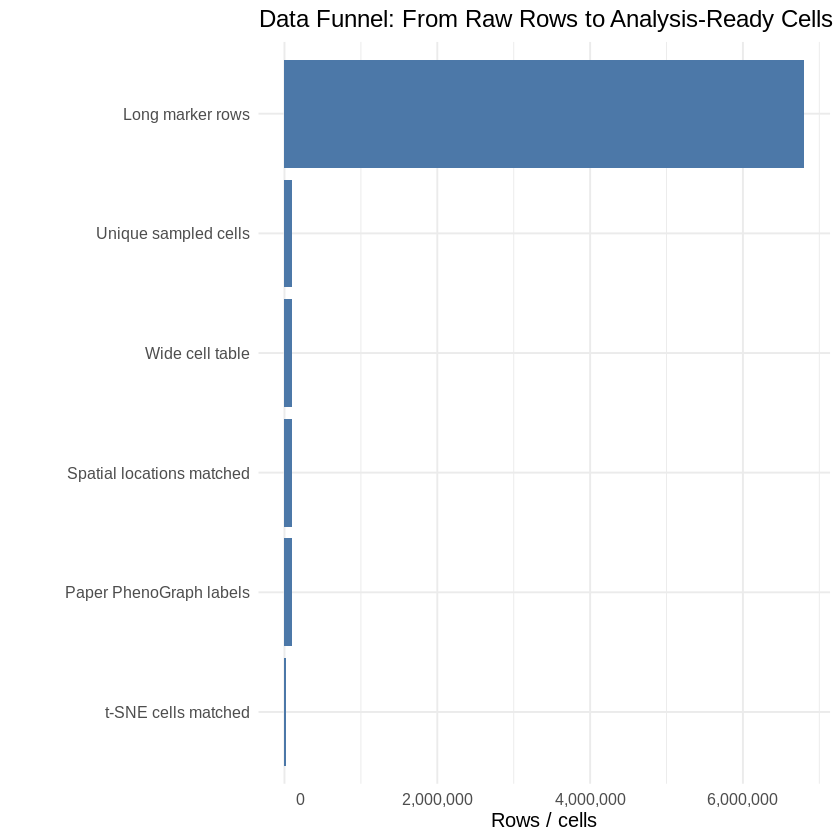

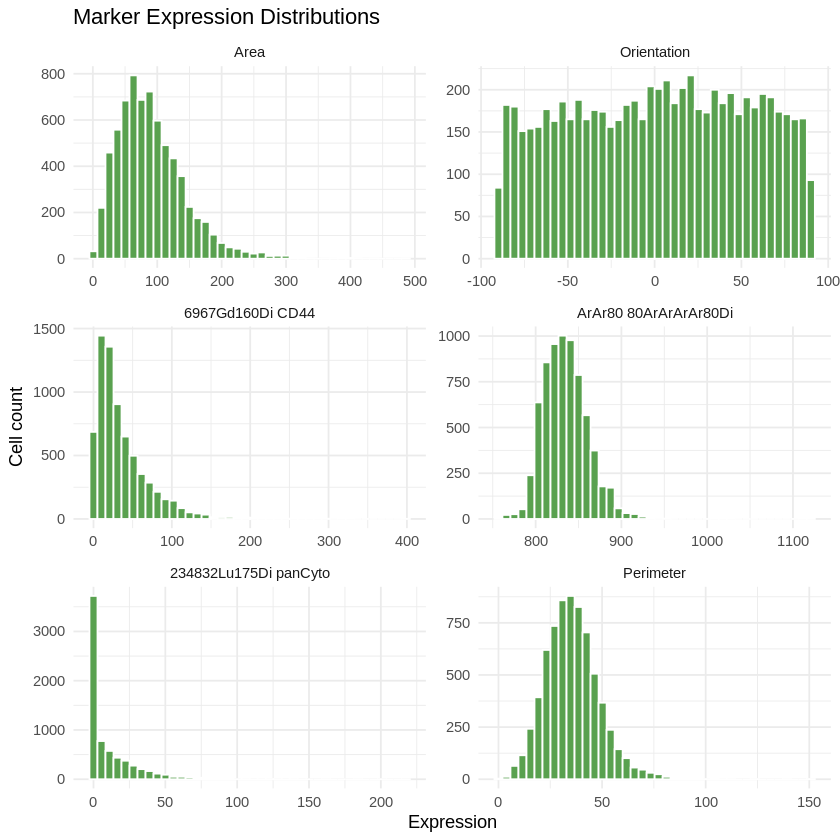

In [39]:
funnel_steps <- c("Long marker rows", "Unique sampled cells", "Wide cell table",
                  "Spatial locations matched", "Paper PhenoGraph labels", "t-SNE cells matched")
funnel_counts <- c(
  nrow(sc_subset),
  data.table::uniqueN(sc_subset$id),
  nrow(sc_wide),
  if (exists("locations")) nrow(locations) else NA,
  if (exists("pg_paper")) nrow(pg_paper) else NA,
  if (exists("tsne_paper")) nrow(tsne_paper) else NA
)

funnel_df <- data.frame(
  Step = factor(funnel_steps, levels = rev(funnel_steps)),
  Count = funnel_counts
)

print(
  ggplot(funnel_df, aes(x = Step, y = Count)) +
    geom_col(fill = "#4C78A8") +
    coord_flip() +
    scale_y_continuous(labels = function(x) format(x, big.mark = ",", scientific = FALSE)) +
    labs(
      title = "Data Funnel: From Raw Rows to Analysis-Ready Cells",
      x = NULL,
      y = "Rows / cells"
    ) +
    theme_minimal(base_size = 12)
)

exclude_cols <- unique(c(
  "core", "CellId", "id", "ImageNumber", "ObjectNumber", "ObjectNumber_renamed",
  "Location_Center_X", "Location_Center_Y", pg_cluster_col
))
candidate_markers <- setdiff(names(sc_wide), exclude_cols)
candidate_markers <- candidate_markers[
  vapply(sc_wide[, ..candidate_markers], is.numeric, logical(1))
]

set.seed(42)
vis_cells <- sc_wide[sample(.N, min(.N, 7000))]
marker_var <- sapply(vis_cells[, ..candidate_markers], var, na.rm = TRUE)
top_markers <- names(sort(marker_var, decreasing = TRUE))[1:6]

marker_long <- data.table::melt(
  vis_cells[, ..top_markers],
  measure.vars = top_markers,
  variable.name = "Marker",
  value.name = "Expression"
)
marker_long <- marker_long[is.finite(Expression)]

print(
  ggplot(marker_long, aes(x = Expression)) +
    geom_histogram(bins = 40, fill = "#59A14F", color = "white") +
    facet_wrap(~ Marker, scales = "free", ncol = 2) +
    labs(
      title = "Marker Expression Distributions",
      x = "Expression",
      y = "Cell count"
    ) +
    theme_minimal(base_size = 11)
)

In [16]:
pg_cluster_col <- setdiff(names(pg_paper), c("core", "CellId", "id"))
if (length(pg_cluster_col) != 1) {
  pg_cluster_col <- "PhenoGraph"
}
stopifnot(pg_cluster_col %in% names(sc_wide))

morph_features <- c(
  "Area", "Perimeter", "Eccentricity", "Solidity",
  "Number_Neighbors", "Percent_Touching", "Circularity",
  "AspectRatio", "MajorAxis", "MinorAxis", "Orientation",
  "MajorAxisLength", "MinorAxisLength", "Extent", "EulerNumber"
)

technical_patterns <- paste(
  c("Rutheni", "Xe", "Pb", "Hg", "ArAr", "In115", "I127", "Iridium", "ImageId"),
  collapse = "|"
)

candidate_markers <- intersect(unique(sc_subset$channel), names(sc_wide))
protein_markers <- setdiff(candidate_markers, morph_features)
protein_markers <- protein_markers[!grepl(technical_patterns, protein_markers, ignore.case = TRUE)]
protein_markers <- protein_markers[vapply(sc_wide[, ..protein_markers], is.numeric, logical(1))]

cat("Protein/marker columns selected:", length(protein_markers), "\n")
cat("  ", paste(head(protein_markers, 10), collapse = ", "), "...\n")

set.seed(CONFIG$SEED)
idx_sample <- sample(nrow(sc_wide), min(10000, nrow(sc_wide)))
sc_sample <- sc_wide[idx_sample, ]

expr_matrix <- as.matrix(sc_sample[, ..protein_markers])
expr_matrix[is.na(expr_matrix)] <- 0
expr_asin <- asinh(expr_matrix / 5)
rm(expr_matrix)

message("Running PhenoGraph on ", nrow(expr_asin), " cells with k=20...")
pg_result <- Rphenograph::Rphenograph(expr_asin, k = 20)
sc_sample$cluster_demo <- as.integer(igraph::membership(pg_result[[2]]))

n_clusters <- length(unique(sc_sample$cluster_demo))
cat("Number of demo clusters found:", n_clusters, "\n")

cluster_profiles <- sc_sample[
  , lapply(.SD, mean, na.rm = TRUE),
  by = cluster_demo,
  .SDcols = protein_markers
]

cat("\nCluster mean expression profiles (first 5 markers):\n")
print(cluster_profiles[, c("cluster_demo", head(protein_markers, 5)), with = FALSE])

Protein/marker columns selected: 33 
   1021522Tm169Di EGFR, 1031747Er167Di ECadhe, 112475Gd156Di Estroge, 117792Dy163Di GATA3, 1261726In113Di Histone, 1441101Er168Di Ki67, 174864Nd148Di SMA, 1921755Sm149Di Vimenti, 198883Yb176Di cleaved, 201487Eu151Di cerbB ...


Running PhenoGraph on 10000 cells with k=20...

Run Rphenograph starts:
  -Input data of 10000 rows and 33 columns
  -k is set to 20



  Finding nearest neighbors...DONE ~ 1.472 s
  Compute jaccard coefficient between nearest-neighbor sets...DONE ~ 1.56 s
  Build undirected graph from the weighted links...DONE ~ 1.007 s
  Run louvain clustering on the graph ...DONE ~ 1.133 s


Run Rphenograph DONE, totally takes 5.17200000000139s.



  Return a community class
  -Modularity value: 0.8257933 
  -Number of clusters: 30Number of demo clusters found: 30 

Cluster mean expression profiles (first 5 markers):
    cluster_demo 1021522Tm169Di EGFR 1031747Er167Di ECadhe
           <int>               <num>                 <num>
 1:            1           0.4523491             1.1689897
 2:            2           0.4153181             1.0913039
 3:            3           1.1595404             2.6261421
 4:            4           0.4707667             2.3364954
 5:            5           0.2361603             0.8196864
 6:            6           0.5282699             4.5994249
 7:            7           0.4415818             1.2858789
 8:            8           0.6432932             3.7402123
 9:            9           0.4597738             4.8774086
10:           10           0.6389103             5.4656756
11:           11           0.2623248             2.8142438
12:           12           0.5513222             1.8860602
13

In [17]:
paper_cluster_col <- pg_cluster_col
sc_sample$cluster_paper <- sc_wide[[paper_cluster_col]][idx_sample]

valid <- !is.na(sc_sample$cluster_demo) & !is.na(sc_sample$cluster_paper)
cat("Cells with both labels:", sum(valid), "/", nrow(sc_sample), "\n")

ct <- table(sc_sample$cluster_demo[valid], sc_sample$cluster_paper[valid])
cat("\nCross-tabulation dimensions:", nrow(ct), "demo clusters x", ncol(ct), "paper clusters\n")
print(ct)

n <- sum(ct)
sum_cells <- sum(choose(ct, 2))
sum_a <- sum(choose(rowSums(ct), 2))
sum_b <- sum(choose(colSums(ct), 2))
total_pairs <- choose(n, 2)

expected <- sum_a * sum_b / total_pairs
max_val <- (sum_a + sum_b) / 2
denom <- max_val - expected

ari <- ifelse(denom == 0, NA_real_, (sum_cells - expected) / denom)

cat(sprintf("\nAdjusted Rand Index (ARI): %.4f\n", ari))
cat("Interpretation: >0.9 = excellent, >0.8 = good, >0.65 = moderate\n")

if (!is.na(ari) && ari > 0.7) {
  message("SUCCESS: Demo clustering strongly agrees with the paper.")
} else {
  message("NOTE: Moderate/low agreement can happen because this is only a 10k-cell subsample.")
}

Cells with both labels: 10000 / 10000 

Cross-tabulation dimensions: 30 demo clusters x 71 paper clusters
    
       1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  1   59  56 241  13   0  93   0   2   0  61   0   0   0   0   8   2   0   4
  2   63 313  72  12   2  47   6  15   0  18   8   0   0   0   2   2   2   4
  3    0   0   0   0   2   0   0   0   0   1   0   0   0   0   0   0   0   1
  4    8   6   3   2   0   1   0   0   0   1 134   0   0   0   1   0   0   1
  5  254  25  28  78   3  16  28   1   0  44   0   0   0   1   6   1   4   1
  6   41  22  28   1  11   7   8   3   4   4   3   7   1   3  12   2   3  16
  7  161  77 247   9   0  33   5   6   0  83   8   0   0   0  85  14   7   7
  8    0   4   0   0   0   2   0  52   0   0   0   0   0   0   0   0   2   1
  9   30   1   1   3  65   8  32  50 171   1  13 121 115  94   0  20   6  20
  10   0   0   0   0   0   1   0   3  19   0   0   3   2  28   0   0   2   2
  11  84   3   0   9  50   3  79  28   9  

NOTE: Moderate/low agreement can happen because this is only a 10k-cell subsample.



Each row is a demo PhenoGraph cluster. Red means that marker is high for that cluster.
Demo-vs-paper ARI: 0.131 


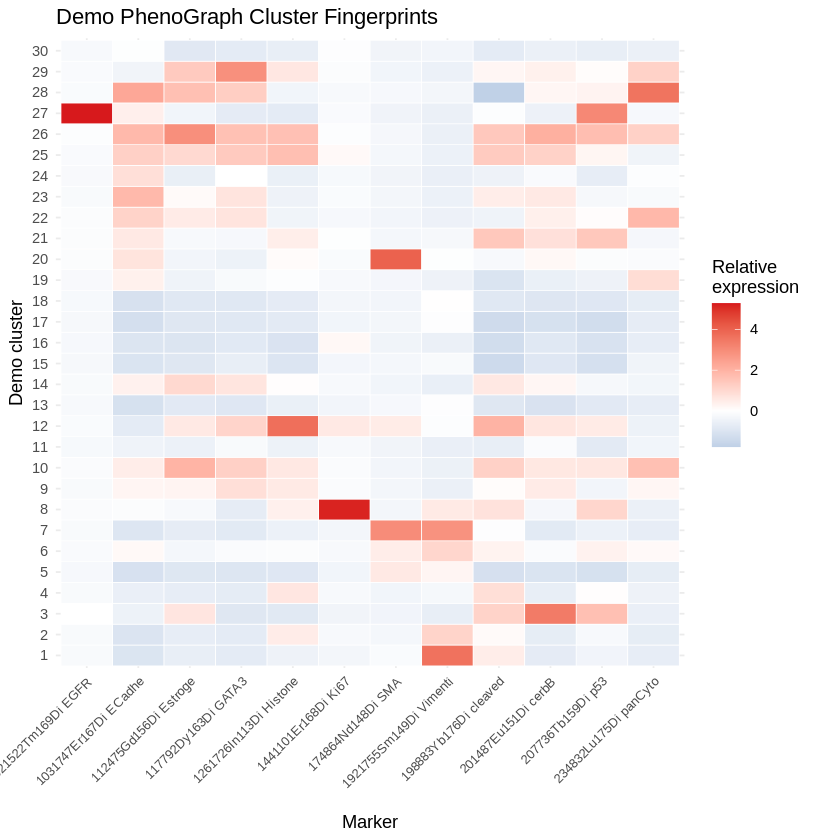

In [40]:
hm_markers <- head(protein_markers, min(12, length(protein_markers)))

hm <- as.data.table(cluster_profiles[, c("cluster_demo", hm_markers), with = FALSE])
hm_long <- data.table::melt(
  hm,
  id.vars = "cluster_demo",
  variable.name = "Marker",
  value.name = "MeanExpression"
)

hm_long[, Z := as.numeric(scale(MeanExpression)), by = Marker]

cat("Each row is a demo PhenoGraph cluster. Red means that marker is high for that cluster.\n")
cat("Demo-vs-paper ARI:", round(ari, 3), "\n")

print(
  ggplot(hm_long, aes(x = Marker, y = factor(cluster_demo), fill = Z)) +
    geom_tile(color = "white", linewidth = 0.2) +
    scale_fill_gradient2(low = "#2C7BB6", mid = "white", high = "#D7191C",
                         midpoint = 0, na.value = "grey90") +
    labs(
      title = "Demo PhenoGraph Cluster Fingerprints",
      x = "Marker",
      y = "Demo cluster",
      fill = "Relative\nexpression"
    ) +
    theme_minimal(base_size = 11) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 8))
)

t-SNE columns: tsne1, tnse2 
Cells in t-SNE map after matching subset labels: 19838 


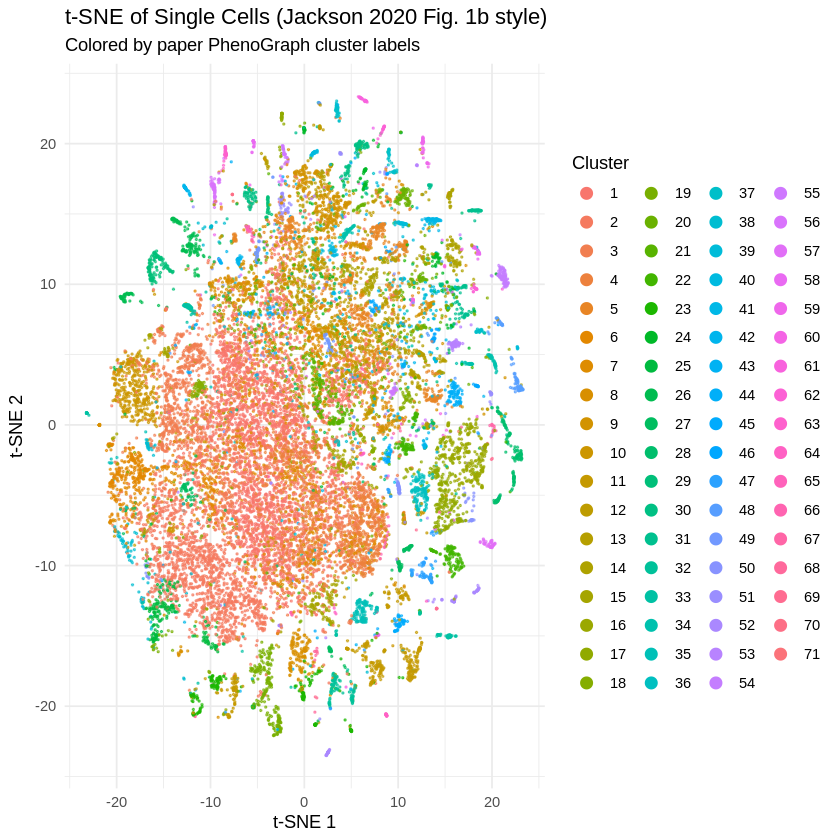

In [18]:
tsne_cols <- setdiff(names(tsne_paper), c("core", "CellId", "id"))
cat("t-SNE columns:", paste(tsne_cols, collapse = ", "), "\n")

tsne_axes <- tsne_cols[1:2]

tsne_merged <- merge(
  tsne_paper,
  sc_wide[, c("core", "CellId", pg_cluster_col), with = FALSE],
  by = c("core", "CellId"),
  all.x = TRUE
)

tsne_merged <- tsne_merged[!is.na(tsne_merged[[pg_cluster_col]])]

cat("Cells in t-SNE map after matching subset labels:", nrow(tsne_merged), "\n")

p_tsne <- ggplot(
  tsne_merged,
  aes(
    x = .data[[tsne_axes[1]]],
    y = .data[[tsne_axes[2]]],
    color = as.factor(.data[[pg_cluster_col]])
  )
) +
  geom_point(size = 0.3, alpha = 0.6) +
  theme_minimal() +
  labs(
    title = "t-SNE of Single Cells (Jackson 2020 Fig. 1b style)",
    subtitle = "Colored by paper PhenoGraph cluster labels",
    x = "t-SNE 1",
    y = "t-SNE 2",
    color = "Cluster"
  ) +
  guides(color = guide_legend(override.aes = list(size = 3, alpha = 1))) +
  theme(legend.position = "right")

print(p_tsne)

In [19]:
cluster_col <- pg_cluster_col

pheno_counts <- sc_wide[
  !is.na(get(cluster_col)),
  .N,
  by = c("core", cluster_col)
]

core_totals <- sc_wide[, .(Total_Cells = .N), by = "core"]

pheno_abund <- merge(pheno_counts, core_totals, by = "core")
pheno_abund[, Abundance := (N / Total_Cells) * 100]
setnames(pheno_abund, old = cluster_col, new = "ClusterID")

abund_wide <- dcast(
  pheno_abund,
  core ~ paste0("Cluster_", ClusterID),
  value.var = "Abundance",
  fill = 0
)

cat(
  "Phenotype abundance matrix:",
  nrow(abund_wide), "patients/cores x",
  ncol(abund_wide) - 1, "phenotypes\n"
)

meta_cores <- unique(meta_data$core)
abund_cores <- unique(abund_wide$core)

cat("Metadata cores:", length(meta_cores), "\n")
cat("Abundance cores:", length(abund_cores), "\n")
cat("Intersection:", length(intersect(meta_cores, abund_cores)), "\n")

Phenotype abundance matrix: 381 patients/cores x 71 phenotypes
Metadata cores: 376 
Abundance cores: 381 
Intersection: 376 


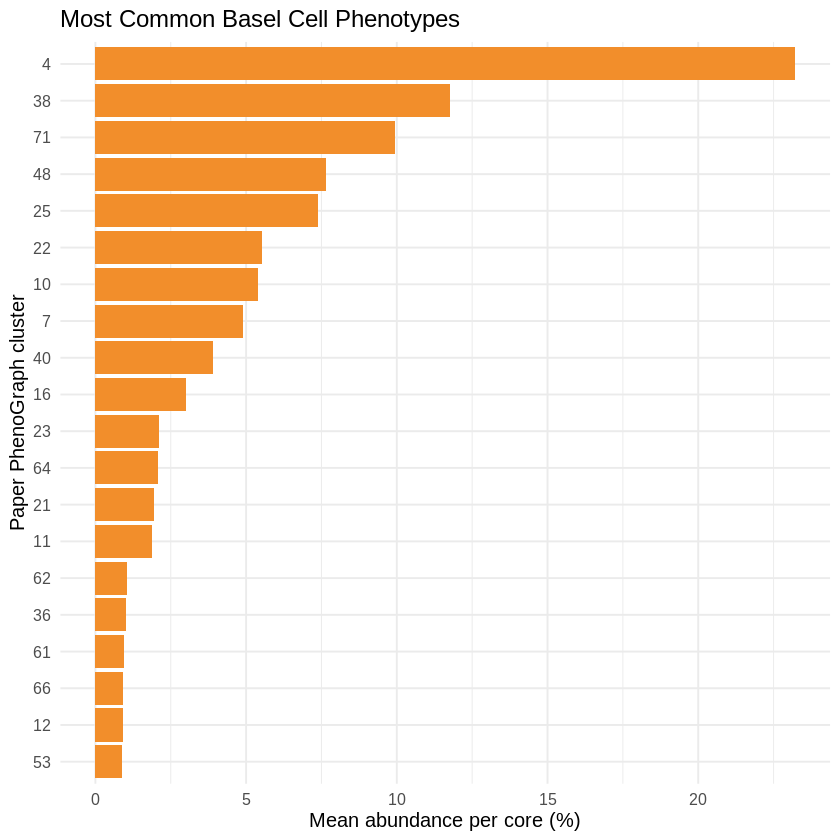

In [41]:
cluster_cols <- grep("^Cluster_", names(abund_wide), value = TRUE)

mean_abund <- data.table(
  Phenotype = cluster_cols,
  MeanPercent = sapply(abund_wide[, ..cluster_cols], mean, na.rm = TRUE)
)
mean_abund[, Phenotype := sub("^Cluster_", "", Phenotype)]

top_abund <- mean_abund[order(-MeanPercent)][1:min(20, .N)]

print(
  ggplot(top_abund, aes(x = reorder(Phenotype, MeanPercent), y = MeanPercent)) +
    geom_col(fill = "#F28E2B") +
    coord_flip() +
    labs(
      title = "Most Common Basel Cell Phenotypes",
      x = "Paper PhenoGraph cluster",
      y = "Mean abundance per core (%)"
    ) +
    theme_minimal(base_size = 12)
)

Using time column: OSmonth 
Using status column: Patientstatus 
Patients in survival analysis: 376 
Events (deaths): 102 
Phenotypes to test: 71 


Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
“Loglik converged before variable  1 ; coefficient may be infinite. ”
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
“Loglik converged before variable  1 ; coefficient may be infinite. ”
Warning message in coxph.fit(X, Y, istrat, offset, init, control, weights = weights, :
“Loglik converged before variable  1 ; coefficient may be infinite. ”



=== Top 5 most significant phenotypes ===
    Phenotype      PValue        HR  HR_Lower  HR_Upper High_Median Low_Median
38 Cluster_43 0.008163597 0.5852148 0.3916047 0.8745462   0.6578947          0
7  Cluster_15 0.010339794 0.5997014 0.4039870 0.8902310   1.6485507          0
65 Cluster_68 0.013583108 0.5447612 0.3338119 0.8890178   0.3496503          0
28 Cluster_34 0.019422220 3.1086208 1.1411132 8.4685054   0.6338449          0
50 Cluster_54 0.022656984 0.3957554 0.1732660 0.9039416   0.3888387          0
        PAdj Significant
38 0.3214669       FALSE
7  0.3214669       FALSE
65 0.3214669       FALSE
28 0.3217292       FALSE
50 0.3217292       FALSE

Significant phenotypes (FDR < 0.05): 0 / 71 


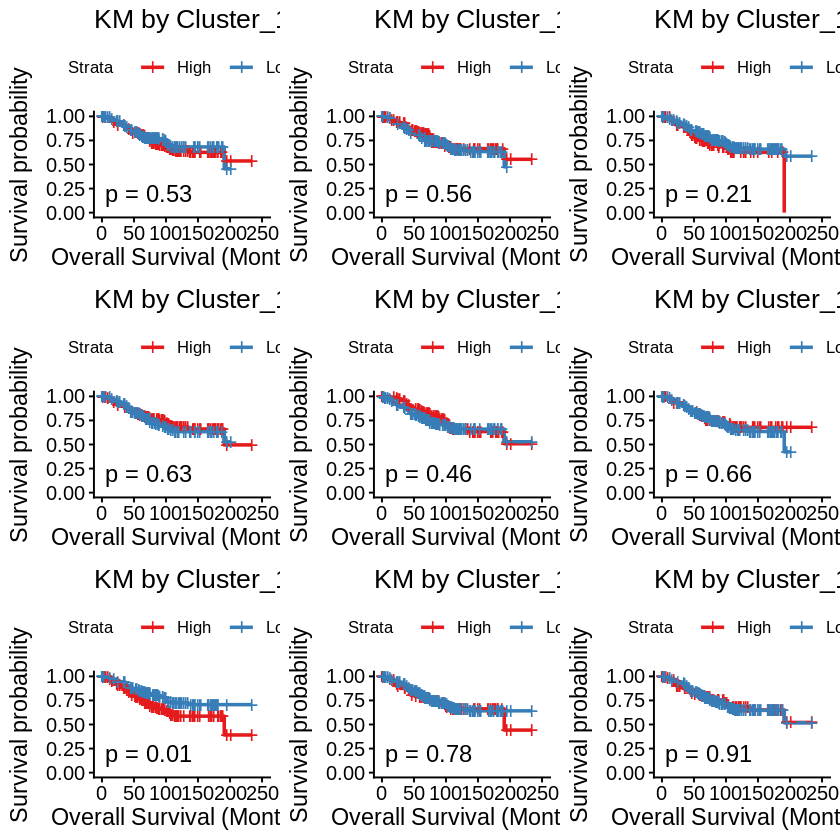

In [20]:
surv_data <- as.data.frame(merge(meta_data, abund_wide, by = "core", all = FALSE))

time_col <- intersect(
  c("OSmonth", "OS.month", "OS_time", "Survival_time", "Overall_Survival_Months"),
  names(surv_data)
)[1]

status_col <- intersect(
  c("Patientstatus", "PatientStatus", "Status", "OSstatus", "event", "Event"),
  names(surv_data)
)[1]

if (is.na(time_col) || is.na(status_col)) {
  stop("Could not find survival columns. Available: ", paste(names(surv_data), collapse = ", "))
}

cat("Using time column:", time_col, "\n")
cat("Using status column:", status_col, "\n")

surv_data$Time_Months <- as.numeric(surv_data[[time_col]])
surv_data$Status_Binary <- ifelse(
  grepl("death", surv_data[[status_col]], ignore.case = TRUE),
  1L,
  0L
)

surv_data <- surv_data[
  !is.na(surv_data$Time_Months) &
    !is.na(surv_data$Status_Binary) &
    surv_data$Time_Months >= 0,
]

cat("Patients in survival analysis:", nrow(surv_data), "\n")
cat("Events (deaths):", sum(surv_data$Status_Binary), "\n")

cluster_cols <- grep("^Cluster_", names(surv_data), value = TRUE)
cat("Phenotypes to test:", length(cluster_cols), "\n")

km_results <- data.frame(
  Phenotype = character(),
  PValue = numeric(),
  HR = numeric(),
  HR_Lower = numeric(),
  HR_Upper = numeric(),
  High_Median = numeric(),
  Low_Median = numeric(),
  stringsAsFactors = FALSE
)

plot_list <- list()

for (cl in cluster_cols) {
  median_val <- median(surv_data[[cl]], na.rm = TRUE)
  surv_data$Group <- ifelse(surv_data[[cl]] > median_val, "High", "Low")

  if (length(unique(surv_data$Group)) < 2) next

  tab <- table(surv_data$Group, surv_data$Status_Binary)
  if (nrow(tab) < 2 || ncol(tab) < 2) next

  s_obj <- Surv(surv_data$Time_Months, surv_data$Status_Binary)

  cox_fit <- tryCatch(
    coxph(s_obj ~ Group, data = surv_data),
    error = function(e) NULL
  )
  if (is.null(cox_fit)) next

  hr <- exp(coef(cox_fit))[1]
  ci <- exp(confint(cox_fit))[1,]
  pval <- summary(cox_fit)$sctest["pvalue"]

  km_results <- rbind(
    km_results,
    data.frame(
      Phenotype = cl,
      PValue = as.numeric(pval),
      HR = as.numeric(hr),
      HR_Lower = as.numeric(ci[1]),
      HR_Upper = as.numeric(ci[2]),
      High_Median = median(surv_data[[cl]][surv_data$Group == "High"], na.rm = TRUE),
      Low_Median = median(surv_data[[cl]][surv_data$Group == "Low"], na.rm = TRUE)
    )
  )

  if (length(plot_list) < 9) {
    fit <- survfit(s_obj ~ Group, data = surv_data)
    p <- ggsurvplot(
      fit,
      data = surv_data,
      pval = TRUE,
      conf.int = FALSE,
      risk.table = FALSE,
      legend.labs = c("High", "Low"),
      title = paste("KM by", cl),
      xlab = "Overall Survival (Months)",
      palette = c("#E41A1C", "#377EB8")
    )$plot
    plot_list[[cl]] <- p
  }
}

km_results <- km_results[order(km_results$PValue),]
km_results$PAdj <- p.adjust(km_results$PValue, method = "BH")
km_results$Significant <- km_results$PAdj < 0.05

cat("\n=== Top 5 most significant phenotypes ===\n")
print(head(km_results, 5))

sig <- km_results[km_results$Significant,]
cat("\nSignificant phenotypes (FDR < 0.05):", nrow(sig), "/", nrow(km_results), "\n")

if (length(plot_list) > 0) {
  gridExtra::grid.arrange(grobs = plot_list, ncol = 3)
}

Warning message:
“`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”
`height` was translated to `width`.


Clinical covariates available: Subtype 
Multivariable Cox formula:
   Surv(Time_Months, Status_Binary) ~ Cluster_7 + Cluster_2 + Cluster_3 + Cluster_4 + Cluster_1 + Subtype 

=== Multivariable Cox Model ===
Call:
coxph(formula = as.formula(formula_str), data = surv_data)

  n= 376, number of events= 102 

                    coef  exp(coef)   se(coef)      z Pr(>|z|)    
Cluster_7     -0.0049951  0.9950174  0.0179479 -0.278 0.780775    
Cluster_2     -0.0083788  0.9916562  0.0108919 -0.769 0.441737    
Cluster_3     -0.0008311  0.9991693  0.0085861 -0.097 0.922893    
Cluster_4      0.0013230  1.0013238  0.0061820  0.214 0.830547    
Cluster_1     -0.0018025  0.9981991  0.0100650 -0.179 0.857872    
SubtypePR-ER- -0.8963464  0.4080578  0.5222559 -1.716 0.086108 .  
SubtypePR-ER+ -1.1194203  0.3264690  0.5256359 -2.130 0.033201 *  
SubtypePR+ER- -1.0059202  0.3657080  0.9142102 -1.100 0.271194    
SubtypePR+ER+ -1.8964203  0.1501050  0.5208253 -3.641 0.000271 ***
---
Signif. codes:  0 ‘

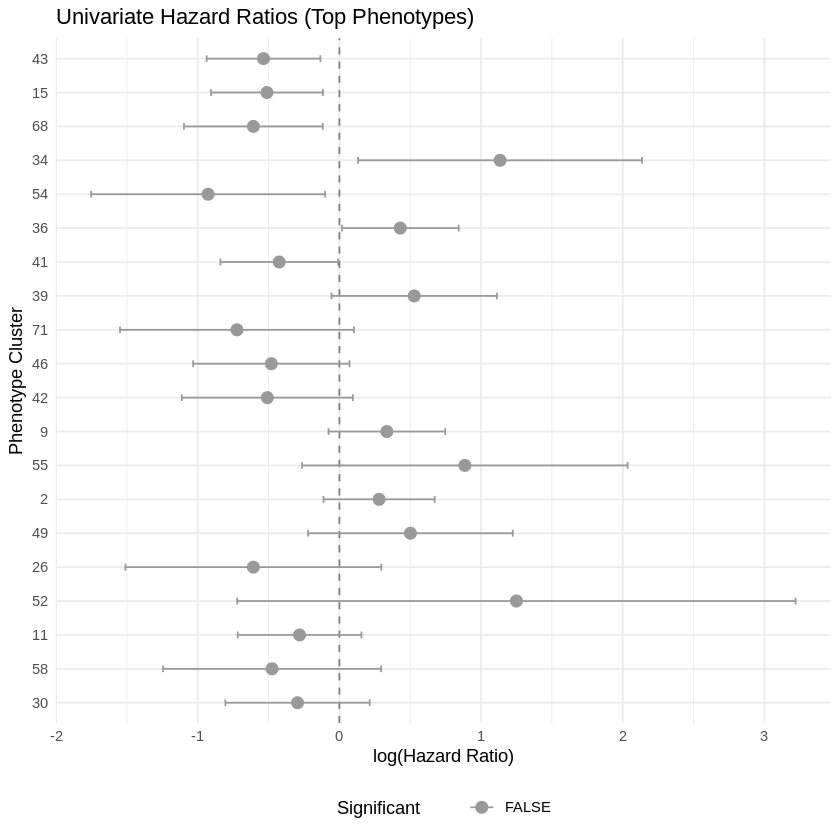

In [21]:
if (!exists("km_results") || nrow(km_results) == 0) {
  stop("km_results is empty. Run Cell 9 first.")
}

km_results$logHR <- log(km_results$HR)
km_results$SE <- (log(km_results$HR_Upper) - log(km_results$HR_Lower)) / (2 * 1.96)
km_results$Phenotype_short <- sub("^Cluster_", "", km_results$Phenotype)

top20 <- head(km_results, min(20, nrow(km_results)))
top20$Phenotype_short <- factor(top20$Phenotype_short, levels = rev(top20$Phenotype_short))

p_forest <- ggplot(top20, aes(x = logHR, y = Phenotype_short)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50") +
  geom_point(aes(color = Significant), size = 3) +
  geom_errorbarh(
    aes(
      xmin = logHR - 1.96 * SE,
      xmax = logHR + 1.96 * SE,
      color = Significant
    ),
    height = 0.2
  ) +
  scale_color_manual(values = c("FALSE" = "gray60", "TRUE" = "red")) +
  labs(
    title = "Univariate Hazard Ratios (Top Phenotypes)",
    x = "log(Hazard Ratio)",
    y = "Phenotype Cluster"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

print(p_forest)

top5_abundant <- tail(names(sort(colMeans(surv_data[cluster_cols], na.rm = TRUE))), 5)

candidate_clinical <- c("Age", "TumorStage", "Subtype", "Grade", "ER", "PR", "HER2")
clinical_avail <- intersect(candidate_clinical, names(surv_data))

cat("Clinical covariates available:", paste(clinical_avail, collapse = ", "), "\n")

predictors <- c(top5_abundant, clinical_avail)

if (length(predictors) == 0) {
  cox_multi <- NULL
  message("No predictors available for multivariable Cox model.")
} else {
  formula_str <- paste(
    "Surv(Time_Months, Status_Binary) ~",
    paste(predictors, collapse = " + ")
  )

  cat("Multivariable Cox formula:\n  ", formula_str, "\n")

  cox_multi <- tryCatch(
    coxph(as.formula(formula_str), data = surv_data),
    error = function(e) {
      message("Cox model failed: ", e$message)
      NULL
    }
  )
}

if (!is.null(cox_multi)) {
  cat("\n=== Multivariable Cox Model ===\n")
  print(summary(cox_multi))

  cat("\n=== Proportional Hazards Test (cox.zph) ===\n")
  zph_test <- survival::cox.zph(cox_multi)
  print(zph_test)

  sig_ph <- any(zph_test$table[, "p"] < 0.05, na.rm = TRUE)
  if (sig_ph) {
    cat("WARNING: Some covariates violate PH assumption (p<0.05).\n")
  } else {
    cat("PH assumption holds for all covariates.\n")
  }
}

In [30]:
has_spatial <- all(c("Location_Center_X", "Location_Center_Y") %in% names(sc_wide))
cat("Spatial coordinates available:", has_spatial, "\n")

if (has_spatial) {
  sample_cores <- unique(sc_wide$core)[1:min(5, length(unique(sc_wide$core)))]
  cat("Analyzing", length(sample_cores), "sample cores for spatial demo...\n")

  spatial_rows <- list()

  for (cr in sample_cores) {
    core_cells <- sc_wide[sc_wide$core == cr, ]
    core_cells <- core_cells[
      !is.na(core_cells$Location_Center_X) &
        !is.na(core_cells$Location_Center_Y) &
        !is.na(core_cells[[pg_cluster_col]]),
    ]

    if (nrow(core_cells) < 50) {
      message("Skipping core ", cr, ": fewer than 50 usable cells.")
      next
    }

    coords <- as.matrix(core_cells[, .(Location_Center_X, Location_Center_Y)])
    n_cells <- nrow(core_cells)
    k <- min(20, n_cells - 1)

    nn_result <- RANN::nn2(coords, coords, k = k + 1)
    nn_idx <- nn_result$nn.idx[, 2:(k + 1), drop = FALSE]

    cell_clusters <- core_cells[[pg_cluster_col]]
    nn_clusters <- matrix(cell_clusters[nn_idx], nrow = n_cells, ncol = k)

    cluster_props <- sort(table(cell_clusters) / length(cell_clusters), decreasing = TRUE)
    top_clusters <- names(cluster_props)[1:min(3, length(cluster_props))]

    row <- data.table(
      core = cr,
      cells_analyzed = n_cells,
      neighbor_k = k,
      unique_clusters = length(unique(cell_clusters)),
      top_cluster_1 = top_clusters[1],
      top_cluster_1_fraction = as.numeric(cluster_props[1]),
      top_cluster_2 = ifelse(length(top_clusters) >= 2, top_clusters[2], NA),
      top_cluster_2_fraction = ifelse(length(top_clusters) >= 2, as.numeric(cluster_props[2]), NA),
      top_cluster_3 = ifelse(length(top_clusters) >= 3, top_clusters[3], NA),
      top_cluster_3_fraction = ifelse(length(top_clusters) >= 3, as.numeric(cluster_props[3]), NA),
      spatial_mixing_score = mean(nn_clusters != cell_clusters, na.rm = TRUE)
    )

    spatial_rows[[length(spatial_rows) + 1]] <- row
  }

  spatial_results <- if (length(spatial_rows) > 0) {
    data.table::rbindlist(spatial_rows, fill = TRUE)
  } else {
    data.table()
  }

  cat("\nSpatial neighborhood summary:\n")
  print(spatial_results)

  if (nrow(spatial_results) > 0) {
    cat("\nAverage mixing score:", round(mean(spatial_results$spatial_mixing_score), 3), "\n")
    cat("Interpretation: higher mixing means nearby cells are more often different phenotypes.\n")
  }
} else {
  spatial_results <- data.table()
  message("Spatial coordinates not available. Skipping spatial analysis.")
}

Spatial coordinates available: TRUE 
Analyzing 5 sample cores for spatial demo...

Spatial neighborhood summary:
                         core cells_analyzed neighbor_k unique_clusters
                       <char>          <int>      <num>           <int>
1:    BaselTMA_SP41_100_X15Y5            407         20              18
2:    BaselTMA_SP41_101_X10Y8            421         20              18
3:     BaselTMA_SP41_104_X7Y4             68         20               9
4: BaselTMA_SP41_104_X8Y4_175            207         20              21
5: BaselTMA_SP41_104_X8Y4_233            242         20              15
   top_cluster_1 top_cluster_1_fraction top_cluster_2 top_cluster_2_fraction
          <char>                  <num>        <char>                  <num>
1:            30              0.4348894             1              0.1621622
2:            12              0.5581948             1              0.2185273
3:             3              0.6029412             4              0.102941

Plotting Basel core: ZTMA208_slide_2_Cy1x4 
Cells shown: 1361 


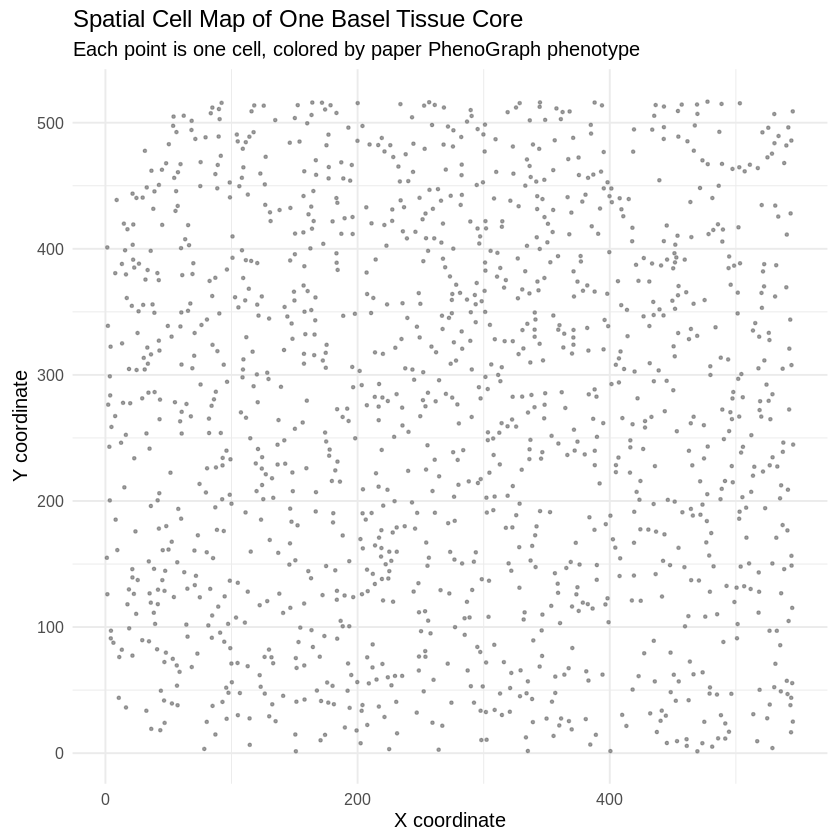

In [42]:
core_counts <- sc_wide[
  !is.na(Location_Center_X) & !is.na(Location_Center_Y),
  .N,
  by = core
][order(-N)]

chosen_core <- core_counts$core[1]

core_plot <- sc_wide[
  core == chosen_core &
    !is.na(Location_Center_X) &
    !is.na(Location_Center_Y)
]

set.seed(42)
core_plot <- core_plot[sample(.N, min(.N, 3000))]

cat("Plotting Basel core:", chosen_core, "\n")
cat("Cells shown:", nrow(core_plot), "\n")

print(
  ggplot(
    core_plot,
    aes(
      x = Location_Center_X,
      y = Location_Center_Y,
      color = factor(.data[[pg_cluster_col]])
    )
  ) +
    geom_point(size = 0.55, alpha = 0.75) +
    coord_fixed() +
    guides(color = "none") +
    labs(
      title = "Spatial Cell Map of One Basel Tissue Core",
      subtitle = "Each point is one cell, colored by paper PhenoGraph phenotype",
      x = "X coordinate",
      y = "Y coordinate"
    ) +
    theme_minimal(base_size = 12)
)

In [31]:
n_sig <- if (exists("km_results")) sum(km_results$Significant, na.rm = TRUE) else NA
n_total <- if (exists("km_results")) nrow(km_results) else NA
n_paper_clusters <- length(unique(sc_wide[[pg_cluster_col]]))
spatial_ok <- exists("has_spatial") && has_spatial

summary_table <- data.frame(
  Item = c(
    "Dataset",
    "Complete cells used",
    "Survival records",
    "Paper clusters used",
    "Demo PhenoGraph",
    "t-SNE cells matched",
    "Survival phenotypes tested",
    "FDR-significant phenotypes",
    "Cox model",
    "Spatial demo"
  ),
  Result = c(
    "Basel TMA public Zenodo data",
    format(nrow(sc_wide), big.mark = ","),
    as.character(nrow(surv_data)),
    as.character(n_paper_clusters),
    paste0("10k cells, ARI ", if (exists("ari")) round(ari, 3) else "N/A"),
    if (exists("tsne_merged")) format(nrow(tsne_merged), big.mark = ",") else "N/A",
    as.character(n_total),
    if (is.na(n_sig)) "N/A" else paste0(n_sig, " / ", n_total),
    if (exists("cox_multi") && !is.null(cox_multi)) "Fitted; PH warnings reported" else "N/A",
    if (exists("spatial_results")) paste0(nrow(spatial_results), " cores") else "N/A"
  )
)

cat("\nVALIDATION SUMMARY\n")
print(summary_table, row.names = FALSE, right = FALSE)

cat("\nKEY TAKEAWAY\n")
cat("This Colab notebook reproduces the paper's analysis logic in principle:\n")
cat("single-cell marker data -> paper phenotype labels -> patient phenotype abundance -> survival models -> spatial neighborhood demo.\n")

cat("\nLIMITATIONS TO REPORT\n")
cat("- Uses a 100k complete-cell subset, not the full original pipeline.\n")
cat("- Independent PhenoGraph is a small demonstration, so ARI is not expected to match the full paper labels.\n")
cat("- No FDR-significant phenotypes appeared in this subset; the full paper uses richer full-scale analyses.\n")
cat("- Cox PH diagnostics showed assumption warnings, so those should be mentioned.\n")


VALIDATION SUMMARY
 Item                       Result                      
 Dataset                    Basel TMA public Zenodo data
 Complete cells used        100,000                     
 Survival records           376                         
 Paper clusters used        71                          
 Demo PhenoGraph            10k cells, ARI 0.131        
 t-SNE cells matched        19,838                      
 Survival phenotypes tested 71                          
 FDR-significant phenotypes 0 / 71                      
 Cox model                  Fitted; PH warnings reported
 Spatial demo               5 cores                     

KEY TAKEAWAY
This Colab notebook reproduces the paper's analysis logic in principle:
single-cell marker data -> paper phenotype labels -> patient phenotype abundance -> survival models -> spatial neighborhood demo.

LIMITATIONS TO REPORT
- Uses a 100k complete-cell subset, not the full original pipeline.
- Independent PhenoGraph is a small demonstrat

In [33]:
if (CONFIG$COHORT %in% c("Zurich", "both")) {

  cat("\n=== Saving Basel results ===\n")

  basel_km_results <- km_results
  basel_cox_multi <- cox_multi
  basel_rowcount <- nrow(surv_data)
  basel_has_spatial <- has_spatial
  basel_spatial_results <- if (exists("spatial_results")) spatial_results else data.table()

  basel_cluster_cols <- cluster_cols
  basel_surv_data <- surv_data

  basel_mean_expr <- sc_wide[
    !is.na(get(pg_cluster_col)),
    lapply(.SD, mean, na.rm = TRUE),
    by = c(pg_cluster_col),
    .SDcols = protein_markers
  ]

  hm_basel <- as.matrix(basel_mean_expr[, ..protein_markers])
  rownames(hm_basel) <- as.character(basel_mean_expr[[pg_cluster_col]])
  hm_basel <- t(scale(t(hm_basel)))

  cat("  Basel survival patients:", basel_rowcount, "\n")
  cat("  Basel clusters:", length(unique(sc_wide[[pg_cluster_col]])), "\n")

  find_existing_file <- function(candidates, pattern = NULL, label = "file") {
    candidates <- unique(candidates[!is.na(candidates) & nzchar(candidates)])

    for (p in candidates) {
      if (file.exists(p)) return(p)
    }

    if (!is.null(pattern)) {
      hits <- list.files(".", pattern = pattern, recursive = TRUE, full.names = TRUE)
      if (length(hits) > 0) return(hits[1])
    }

    stop("Could not find ", label, ". Tried: ", paste(candidates, collapse = ", "))
  }

  cat("\n=== Loading ZurichTMA cohort ===\n")

  zuri_metadata_file <- find_existing_file(
    c(
      CONFIG$FILE_METADATA_ZURI,
      "Dataset_SC/Data_publication/ZurichTMA/Zuri_PatientMetadata.csv",
      "Data_publication/ZurichTMA/Zuri_PatientMetadata.csv"
    ),
    pattern = "^Zuri_PatientMetadata\\.csv$",
    label = "Zurich patient metadata"
  )

  zuri_subset_file <- find_existing_file(
    c(
      CONFIG$FILE_SUBSET_ZURI,
      "subset_SC_dat_zuri.csv"
    ),
    pattern = "^subset_SC_dat_zuri\\.csv$",
    label = "Zurich single-cell subset"
  )

  zuri_pg_file <- find_existing_file(
    c(
      CONFIG$FILE_PG_ZURI,
      "Dataset_SC/Data_publication/ZurichTMA/PG_zurich.csv",
      "Data_publication/ZurichTMA/PG_zurich.csv"
    ),
    pattern = "^PG_zurich\\.csv$",
    label = "Zurich PhenoGraph labels"
  )

  zuri_loc_file <- find_existing_file(
    c(
      CONFIG$FILE_LOCS_ZURI,
      "Dataset_SC/Zurich_SC_locations.csv",
      "Dataset_SC/Zuri_SC_locations.csv",
      "Zurich_SC_locations.csv",
      "Zuri_SC_locations.csv"
    ),
    pattern = "^(Zurich|Zuri)_SC_locations\\.csv$",
    label = "Zurich spatial locations"
  )

  cat("  Metadata file:", zuri_metadata_file, "\n")
  cat("  Single-cell subset:", zuri_subset_file, "\n")
  cat("  PhenoGraph file:", zuri_pg_file, "\n")
  cat("  Locations file:", zuri_loc_file, "\n")

  meta_data <- fread(zuri_metadata_file)
  cat("  Patients/metadata rows:", nrow(meta_data), "\n")

  sc_subset <- fread(zuri_subset_file)
  cat("  Rows in long-format single-cell table:", nrow(sc_subset), "\n")
  cat("  Unique cells:", uniqueN(sc_subset$id), "\n")

  sc_wide <- dcast(sc_subset, core + CellId + id ~ channel, value.var = "mc_counts")
  cat("  Wide dim:", nrow(sc_wide), "x", ncol(sc_wide), "\n")

  cell_key <- unique(sc_wide[, .(id, core, CellId)])

  locations_raw <- fread(zuri_loc_file)
  cat("  Raw locations:", nrow(locations_raw), "\n")
  cat("  Location columns:", paste(names(locations_raw), collapse = ", "), "\n")

  if ("id" %in% names(locations_raw)) {
    loc_value_cols <- setdiff(names(locations_raw), c("id", "core", "CellId"))
    locations <- merge(
      cell_key,
      locations_raw[, c("id", loc_value_cols), with = FALSE],
      by = "id",
      all.x = FALSE,
      all.y = FALSE
    )
    locations[, id := NULL]
  } else if (all(c("core", "CellId") %in% names(locations_raw))) {
    loc_value_cols <- setdiff(names(locations_raw), c("core", "CellId"))
    locations <- locations_raw[, c("core", "CellId", loc_value_cols), with = FALSE]
  } else {
    stop(
      "Cannot merge Zurich locations. Expected either 'id' or both 'core' and 'CellId'. Columns found: ",
      paste(names(locations_raw), collapse = ", ")
    )
  }

  pg_raw <- fread(zuri_pg_file)
  cat("  Raw PG rows:", nrow(pg_raw), "\n")
  cat("  Raw PG columns:", paste(names(pg_raw), collapse = ", "), "\n")

  pg_key_cols <- intersect(c("id", "core", "CellId"), names(pg_raw))
  pg_value_cols <- setdiff(names(pg_raw), pg_key_cols)
  preferred_pg <- grep("PhenoGraph|cluster|meta", pg_value_cols, ignore.case = TRUE, value = TRUE)
  pg_value_col <- if (length(preferred_pg) > 0) preferred_pg[1] else pg_value_cols[1]

  if ("id" %in% names(pg_raw)) {
    pg_paper <- merge(
      cell_key,
      pg_raw[, c("id", pg_value_col), with = FALSE],
      by = "id",
      all.x = FALSE,
      all.y = FALSE
    )
    pg_paper[, id := NULL]
  } else if (all(c("core", "CellId") %in% names(pg_raw))) {
    pg_paper <- merge(
      cell_key[, .(core, CellId)],
      pg_raw[, c("core", "CellId", pg_value_col), with = FALSE],
      by = c("core", "CellId"),
      all.x = FALSE,
      all.y = FALSE
    )
  } else {
    stop("Cannot merge Zurich PG labels. Expected either 'id' or both 'core' and 'CellId'.")
  }

  setnames(pg_paper, pg_value_col, "PhenoGraph")

  sc_wide <- merge(sc_wide, locations, by = c("core", "CellId"), all.x = TRUE)
  sc_wide <- merge(sc_wide, pg_paper, by = c("core", "CellId"), all.x = TRUE)

  pg_cluster_col <- "PhenoGraph"
  has_spatial <- all(c("Location_Center_X", "Location_Center_Y") %in% names(sc_wide))

  cat("\nZurich master table ready:", nrow(sc_wide), "x", ncol(sc_wide), "\n")
  cat("  Cells with spatial X/Y:",
      sum(!is.na(sc_wide$Location_Center_X) & !is.na(sc_wide$Location_Center_Y)),
      "\n")
  cat("  Cells with PhenoGraph label:", sum(!is.na(sc_wide$PhenoGraph)), "\n")

} else {
  cat("Skipping Zurich cohort because CONFIG$COHORT =", CONFIG$COHORT, "\n")
}


=== Saving Basel results ===
  Basel survival patients: 376 
  Basel clusters: 71 

=== Loading ZurichTMA cohort ===
  Metadata file: Dataset_SC/Data_publication/ZurichTMA/Zuri_PatientMetadata.csv 
  Single-cell subset: subset_SC_dat_zuri.csv 
  PhenoGraph file: Dataset_SC/Data_publication/ZurichTMA/PG_zurich.csv 
  Locations file: Dataset_SC/Zurich_SC_locations.csv 
  Patients/metadata rows: 359 
  Rows in long-format single-cell table: 6800000 
  Unique cells: 100000 
  Wide dim: 100000 x 71 
  Raw locations: 433127 
  Location columns: ImageNumber, ObjectNumber, Location_Center_X, Location_Center_Y, core, ObjectNumber_renamed, id 
  Raw PG rows: 401630 
  Raw PG columns: core, CellId, PhenoGraph, id 

Zurich master table ready: 100000 x 77 
  Cells with spatial X/Y: 100000 
  Cells with PhenoGraph label: 92642 


In [34]:
if (CONFIG$COHORT %in% c("Zurich", "both")) {

  cat("\n=== Zurich -> Basel cluster matching ===\n")

  if (!exists("hm_basel")) {
    stop("Missing hm_basel. Run Cell 13 first so Basel profiles are saved.")
  }

  common_markers <- intersect(colnames(hm_basel), names(sc_wide))
  common_markers <- common_markers[
    vapply(sc_wide[, ..common_markers], is.numeric, logical(1))
  ]

  cat("Common markers used for matching:", length(common_markers), "\n")

  if (length(common_markers) < 5) {
    stop("Too few common markers for reliable matching.")
  }

  zuri_mean_expr <- sc_wide[
    !is.na(get(pg_cluster_col)),
    lapply(.SD, mean, na.rm = TRUE),
    by = c(pg_cluster_col),
    .SDcols = common_markers
  ]

  hm_zuri <- as.matrix(zuri_mean_expr[, ..common_markers])
  rownames(hm_zuri) <- as.character(zuri_mean_expr[[pg_cluster_col]])

  hm_zuri <- t(scale(t(hm_zuri)))

  hm_basel_match <- hm_basel[, common_markers, drop = FALSE]

  good_basel_rows <- apply(hm_basel_match, 1, function(x) all(is.finite(x)))
  good_zuri_rows <- apply(hm_zuri, 1, function(x) all(is.finite(x)))

  hm_basel_match <- hm_basel_match[good_basel_rows, , drop = FALSE]
  hm_zuri <- hm_zuri[good_zuri_rows, , drop = FALSE]

  cat("Basel clusters available:", nrow(hm_basel_match), "\n")
  cat("Zurich clusters available:", nrow(hm_zuri), "\n")

  if (nrow(hm_basel_match) == 0 || nrow(hm_zuri) == 0) {
    stop("No usable cluster profiles after filtering.")
  }

  cor_mat <- cor(
    t(hm_zuri),
    t(hm_basel_match),
    method = "pearson",
    use = "pairwise.complete.obs"
  )

  best_basel_idx <- apply(cor_mat, 1, which.max)
  best_cor <- apply(cor_mat, 1, max, na.rm = TRUE)

  cluster_map <- data.table(
    zuri_cluster = rownames(cor_mat),
    basel_cluster = colnames(cor_mat)[best_basel_idx],
    similarity = as.numeric(best_cor)
  )

  cluster_map[, zuri_cluster_numeric := suppressWarnings(as.integer(zuri_cluster))]
  cluster_map[, basel_cluster_numeric := suppressWarnings(as.integer(basel_cluster))]

  cat("\nCluster matching summary:\n")
  print(cluster_map[order(zuri_cluster_numeric)][
    , .(zuri_cluster, basel_cluster, similarity = round(similarity, 3))
  ])

  sc_wide[, zuri_cluster_raw := as.character(get(pg_cluster_col))]
  sc_wide[, PhenoGraph_BaselMatched := cluster_map$basel_cluster[
    match(as.character(get(pg_cluster_col)), cluster_map$zuri_cluster)
  ]]

  pg_cluster_col <- "PhenoGraph_BaselMatched"

  cat("\nCells with matched Basel-style label:",
      sum(!is.na(sc_wide[[pg_cluster_col]])), "\n")
  cat("Matched Basel-style clusters represented:",
      length(unique(na.omit(sc_wide[[pg_cluster_col]]))), "\n")

} else {
  cat("Skipping Zurich cluster matching because CONFIG$COHORT =", CONFIG$COHORT, "\n")
}


=== Zurich -> Basel cluster matching ===
Common markers used for matching: 33 
Basel clusters available: 71 
Zurich clusters available: 41 

Cluster matching summary:
    zuri_cluster basel_cluster similarity
          <char>        <char>      <num>
 1:            1            38      0.997
 2:            2            71      0.978
 3:            3             4      0.986
 4:            4            48      0.971
 5:            5            25      0.997
 6:            6             7      0.966
 7:            7            10      0.970
 8:            8             4      0.989
 9:            9            22      0.977
10:           10            23      0.974
11:           11            64      0.911
12:           12            21      0.984
13:           13            16      0.977
14:           14            40      0.970
15:           15            23      0.985
16:           16            38      0.990
17:           17            11      0.733
18:           18            25    

In [37]:
if (CONFIG$COHORT %in% c("Zurich", "both")) {

  cat("\n=== ZURICH TMA ANALYSIS ===\n")

  pheno_counts <- sc_wide[
    !is.na(get(pg_cluster_col)),
    .N,
    by = c("core", pg_cluster_col)
  ]

  core_totals <- sc_wide[, .(Total_Cells = .N), by = "core"]

  pheno_abund <- merge(pheno_counts, core_totals, by = "core")
  pheno_abund[, Abundance := (N / Total_Cells) * 100]
  setnames(pheno_abund, old = pg_cluster_col, new = "ClusterID")

  abund_wide <- dcast(
    pheno_abund,
    core ~ paste0("Cluster_", ClusterID),
    value.var = "Abundance",
    fill = 0
  )

  cat(
    "Phenotype abundance matrix:",
    nrow(abund_wide), "cores x",
    ncol(abund_wide) - 1, "matched Basel-style phenotypes\n"
  )

  core_overlap <- length(intersect(meta_data$core, abund_wide$core))
  cat("Metadata/abundance core overlap:", core_overlap, "\n")

  surv_data_core <- as.data.frame(merge(meta_data, abund_wide, by = "core", all = FALSE))

  time_col <- intersect(
    c("OSmonth", "OS.month", "OS_time", "Survival_time", "Overall_Survival_Months"),
    names(surv_data_core)
  )[1]

  status_col <- intersect(
    c("Patientstatus", "PatientStatus", "Status", "OSstatus", "event", "Event"),
    names(surv_data_core)
  )[1]

  cat("Candidate time column:", ifelse(is.na(time_col), "none", time_col), "\n")
  cat("Candidate status column:", ifelse(is.na(status_col), "none", status_col), "\n")

  km_results <- data.frame(
    Phenotype = character(),
    PValue = numeric(),
    HR = numeric(),
    HR_Lower = numeric(),
    HR_Upper = numeric(),
    High_Median = numeric(),
    Low_Median = numeric(),
    PAdj = numeric(),
    Significant = logical(),
    stringsAsFactors = FALSE
  )

  cox_multi <- NULL
  zuri_survival_available <- FALSE

  if (!is.na(time_col) && !is.na(status_col)) {
    surv_data_core$Time_Months <- as.numeric(surv_data_core[[time_col]])
    surv_data_core$Status_Binary <- ifelse(
      grepl("death", surv_data_core[[status_col]], ignore.case = TRUE),
      1L,
      0L
    )

    usable_core_surv <- surv_data_core[
      !is.na(surv_data_core$Time_Months) &
        !is.na(surv_data_core$Status_Binary) &
        surv_data_core$Time_Months >= 0,
    ]

    cat("Usable Zurich core-level survival rows:", nrow(usable_core_surv), "\n")

    if (nrow(usable_core_surv) > 0) {
      zuri_survival_available <- TRUE

      cluster_cols <- grep("^Cluster_", names(usable_core_surv), value = TRUE)

      if ("PID" %in% names(usable_core_surv)) {
        surv_data <- as.data.table(usable_core_surv)[
          ,
          c(
            list(
              Time_Months = max(Time_Months, na.rm = TRUE),
              Status_Binary = max(Status_Binary, na.rm = TRUE)
            ),
            lapply(.SD, mean, na.rm = TRUE)
          ),
          by = PID,
          .SDcols = cluster_cols
        ]
        surv_data <- as.data.frame(surv_data)
        cat("Collapsed to patient-level Zurich survival records:", nrow(surv_data), "\n")
      } else {
        surv_data <- usable_core_surv
        cat("Using core-level Zurich survival records:", nrow(surv_data), "\n")
      }

      cluster_cols <- grep("^Cluster_", names(surv_data), value = TRUE)
      cat("Phenotypes to test:", length(cluster_cols), "\n")

      for (cl in cluster_cols) {
        median_val <- median(surv_data[[cl]], na.rm = TRUE)
        surv_data$Group <- ifelse(surv_data[[cl]] > median_val, "High", "Low")

        if (length(unique(surv_data$Group)) < 2) next

        tab <- table(surv_data$Group, surv_data$Status_Binary)
        if (nrow(tab) < 2 || ncol(tab) < 2) next

        s_obj <- Surv(surv_data$Time_Months, surv_data$Status_Binary)

        cox_fit <- tryCatch(
          coxph(s_obj ~ Group, data = surv_data),
          error = function(e) NULL
        )
        if (is.null(cox_fit)) next

        hr <- exp(coef(cox_fit))[1]
        ci <- exp(confint(cox_fit))[1,]
        pval <- summary(cox_fit)$sctest["pvalue"]

        km_results <- rbind(
          km_results,
          data.frame(
            Phenotype = cl,
            PValue = as.numeric(pval),
            HR = as.numeric(hr),
            HR_Lower = as.numeric(ci[1]),
            HR_Upper = as.numeric(ci[2]),
            High_Median = median(surv_data[[cl]][surv_data$Group == "High"], na.rm = TRUE),
            Low_Median = median(surv_data[[cl]][surv_data$Group == "Low"], na.rm = TRUE),
            PAdj = NA_real_,
            Significant = FALSE
          )
        )
      }

      if (nrow(km_results) > 0) {
        km_results <- km_results[order(km_results$PValue),]
        km_results$PAdj <- p.adjust(km_results$PValue, method = "BH")
        km_results$Significant <- km_results$PAdj < 0.05

        cat("\nZurich top 5 phenotype-survival associations:\n")
        print(head(km_results, 5))
        cat("\nZurich FDR-significant phenotypes:",
            sum(km_results$Significant), "/", nrow(km_results), "\n")
      }
    }
  }

  if (!zuri_survival_available) {
    cat("\nZurich survival analysis skipped: no usable non-missing survival rows after merging.\n")
    cat("Zurich will be used for phenotype abundance and spatial/cross-cohort validation only.\n")
    surv_data <- surv_data_core
    cluster_cols <- grep("^Cluster_", names(surv_data), value = TRUE)
  }

  has_spatial <- all(c("Location_Center_X", "Location_Center_Y") %in% names(sc_wide))

  if (has_spatial) {
    sample_cores <- unique(sc_wide$core)[1:min(5, length(unique(sc_wide$core)))]
    spatial_rows <- list()

    for (cr in sample_cores) {
      core_cells <- sc_wide[sc_wide$core == cr, ]
      core_cells <- core_cells[
        !is.na(core_cells$Location_Center_X) &
          !is.na(core_cells$Location_Center_Y) &
          !is.na(core_cells[[pg_cluster_col]]),
      ]

      if (nrow(core_cells) < 50) next

      coords <- as.matrix(core_cells[, .(Location_Center_X, Location_Center_Y)])
      n_cells <- nrow(core_cells)
      k <- min(20, n_cells - 1)

      nn_result <- RANN::nn2(coords, coords, k = k + 1)
      nn_idx <- nn_result$nn.idx[, 2:(k + 1), drop = FALSE]

      cell_clusters <- core_cells[[pg_cluster_col]]
      nn_clusters <- matrix(cell_clusters[nn_idx], nrow = n_cells, ncol = k)

      cluster_props <- sort(table(cell_clusters) / length(cell_clusters), decreasing = TRUE)
      top_clusters <- names(cluster_props)[1:min(3, length(cluster_props))]

      spatial_rows[[length(spatial_rows) + 1]] <- data.table(
        core = cr,
        cells_analyzed = n_cells,
        unique_clusters = length(unique(cell_clusters)),
        top_cluster_1 = top_clusters[1],
        top_cluster_1_fraction = as.numeric(cluster_props[1]),
        spatial_mixing_score = mean(nn_clusters != cell_clusters, na.rm = TRUE)
      )
    }

    spatial_results <- if (length(spatial_rows) > 0) {
      data.table::rbindlist(spatial_rows, fill = TRUE)
    } else {
      data.table()
    }

    cat("\nZurich spatial summary:\n")
    print(spatial_results)

    if (nrow(spatial_results) > 0) {
      cat("Zurich average mixing score:",
          round(mean(spatial_results$spatial_mixing_score), 3), "\n")
    }
  } else {
    spatial_results <- data.table()
    message("Zurich spatial coordinates unavailable.")
  }

  zuri_km_results <- km_results
  zuri_cox_multi <- cox_multi
  zuri_surv_data <- surv_data
  zuri_rowcount <- nrow(surv_data)
  zuri_has_spatial <- has_spatial
  zuri_spatial_results <- spatial_results
  zuri_abund_wide <- abund_wide
  zuri_survival_available <- zuri_survival_available

  cat("\n=== ZURICH TMA ANALYSIS COMPLETE ===\n")

} else {
  cat("Skipping Zurich analysis because CONFIG$COHORT =", CONFIG$COHORT, "\n")
}


=== ZURICH TMA ANALYSIS ===
Phenotype abundance matrix: 353 cores x 29 matched Basel-style phenotypes
Metadata/abundance core overlap: 347 
Candidate time column: OSmonth 
Candidate status column: Patientstatus 
Usable Zurich core-level survival rows: 0 

Zurich survival analysis skipped: no usable non-missing survival rows after merging.
Zurich will be used for phenotype abundance and spatial/cross-cohort validation only.

Zurich spatial summary:
                      core cells_analyzed unique_clusters top_cluster_1
                    <char>          <int>           <int>        <char>
1: ZTMA208_slide_10_By10x4            230              12             4
2: ZTMA208_slide_10_By10x5            271              12            71
3: ZTMA208_slide_10_By10x6            301              14            71
4: ZTMA208_slide_10_By10x7            293              13            71
5: ZTMA208_slide_10_By10x8             74               7             4
   top_cluster_1_fraction spatial_mixing_sc

In [38]:
cat("\n=== CROSS-COHORT COMPARISON: BASEL VS ZURICH ===\n")

get_mix_mean <- function(x) {
  if (is.null(x) || nrow(x) == 0) return(NA_real_)
  mix_col <- intersect(c("spatial_mixing_score", "Spatial_Mixing_Score"), names(x))[1]
  if (is.na(mix_col)) return(NA_real_)
  round(mean(x[[mix_col]], na.rm = TRUE), 3)
}

basel_cluster_cols <- if (exists("basel_surv_data")) {
  grep("^Cluster_", names(basel_surv_data), value = TRUE)
} else {
  character()
}

zuri_cluster_cols <- if (exists("zuri_abund_wide")) {
  grep("^Cluster_", names(zuri_abund_wide), value = TRUE)
} else {
  character()
}

common_clusters <- intersect(basel_cluster_cols, zuri_cluster_cols)

basel_sig <- if (exists("basel_km_results") && nrow(basel_km_results) > 0) {
  sum(basel_km_results$Significant, na.rm = TRUE)
} else {
  NA_integer_
}

basel_total <- if (exists("basel_km_results")) nrow(basel_km_results) else NA_integer_

zuri_sig <- if (exists("zuri_km_results") && nrow(zuri_km_results) > 0) {
  sum(zuri_km_results$Significant, na.rm = TRUE)
} else {
  NA_integer_
}

zuri_total <- if (exists("zuri_km_results")) nrow(zuri_km_results) else NA_integer_

cross_cohort_summary <- data.frame(
  Metric = c(
    "Basel survival records",
    "Zurich metadata/abundance records",
    "Basel phenotypes tested for survival",
    "Zurich matched Basel-style phenotypes",
    "Common Basel-style phenotypes",
    "Basel FDR-significant survival phenotypes",
    "Zurich survival available",
    "Zurich FDR-significant survival phenotypes",
    "Basel spatial demo cores",
    "Zurich spatial demo cores",
    "Mean Basel spatial mixing score",
    "Mean Zurich spatial mixing score"
  ),
  Result = c(
    if (exists("basel_rowcount")) basel_rowcount else NA,
    if (exists("zuri_rowcount")) zuri_rowcount else NA,
    basel_total,
    length(zuri_cluster_cols),
    length(common_clusters),
    ifelse(is.na(basel_sig), "N/A", paste0(basel_sig, " / ", basel_total)),
    if (exists("zuri_survival_available")) as.character(zuri_survival_available) else "N/A",
    ifelse(is.na(zuri_sig) || zuri_total == 0, "N/A", paste0(zuri_sig, " / ", zuri_total)),
    if (exists("basel_spatial_results")) nrow(basel_spatial_results) else NA,
    if (exists("zuri_spatial_results")) nrow(zuri_spatial_results) else NA,
    get_mix_mean(if (exists("basel_spatial_results")) basel_spatial_results else NULL),
    get_mix_mean(if (exists("zuri_spatial_results")) zuri_spatial_results else NULL)
  ),
  stringsAsFactors = FALSE
)

print(cross_cohort_summary, row.names = FALSE, right = FALSE)

cat("\nInterpretation:\n")
cat("- Basel is the main cohort for survival reproduction because it has usable outcome data.\n")
cat("- Zurich independently confirms that the phenotype and spatial workflow can be applied to another TMA cohort.\n")
cat("- Zurich clusters were mapped onto Basel-style phenotypes using marker-profile similarity.\n")

if (exists("zuri_survival_available") && !zuri_survival_available) {
  cat("- Zurich survival concordance is skipped because no usable non-missing survival rows were available after merging.\n")
}

cat("\n=== CROSS-COHORT COMPARISON COMPLETE ===\n")


=== CROSS-COHORT COMPARISON: BASEL VS ZURICH ===
 Metric                                     Result
 Basel survival records                     376   
 Zurich metadata/abundance records          347   
 Basel phenotypes tested for survival       71    
 Zurich matched Basel-style phenotypes      29    
 Common Basel-style phenotypes              29    
 Basel FDR-significant survival phenotypes  0 / 71
 Zurich survival available                  FALSE 
 Zurich FDR-significant survival phenotypes N/A   
 Basel spatial demo cores                   5     
 Zurich spatial demo cores                  5     
 Mean Basel spatial mixing score            0.669 
 Mean Zurich spatial mixing score           0.757 

Interpretation:
- Basel is the main cohort for survival reproduction because it has usable outcome data.
- Zurich independently confirms that the phenotype and spatial workflow can be applied to another TMA cohort.
- Zurich clusters were mapped onto Basel-style phenotypes using marker-

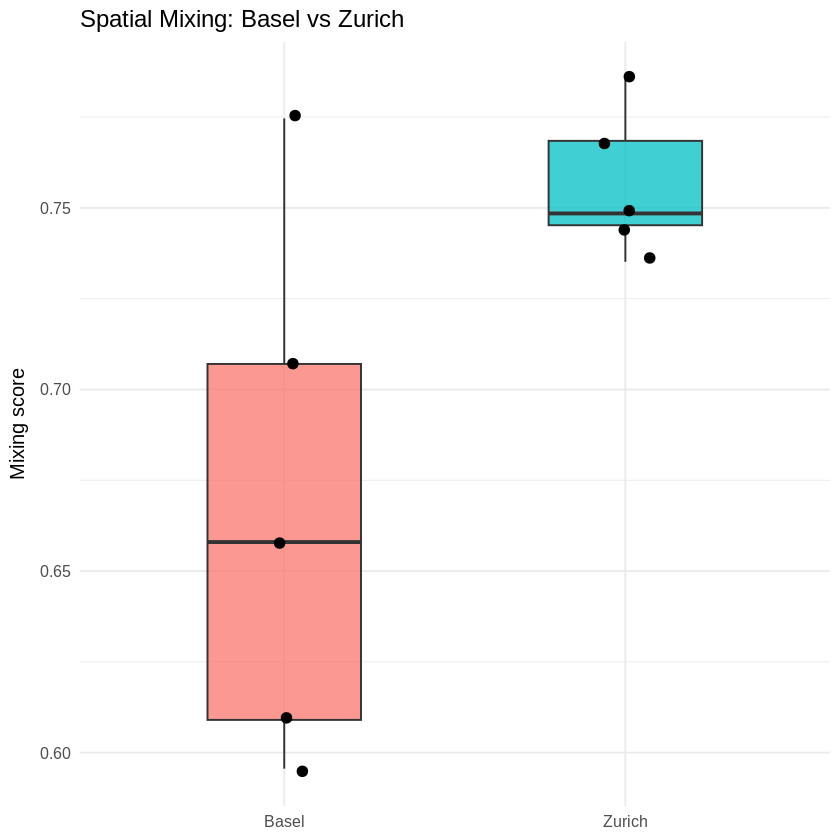

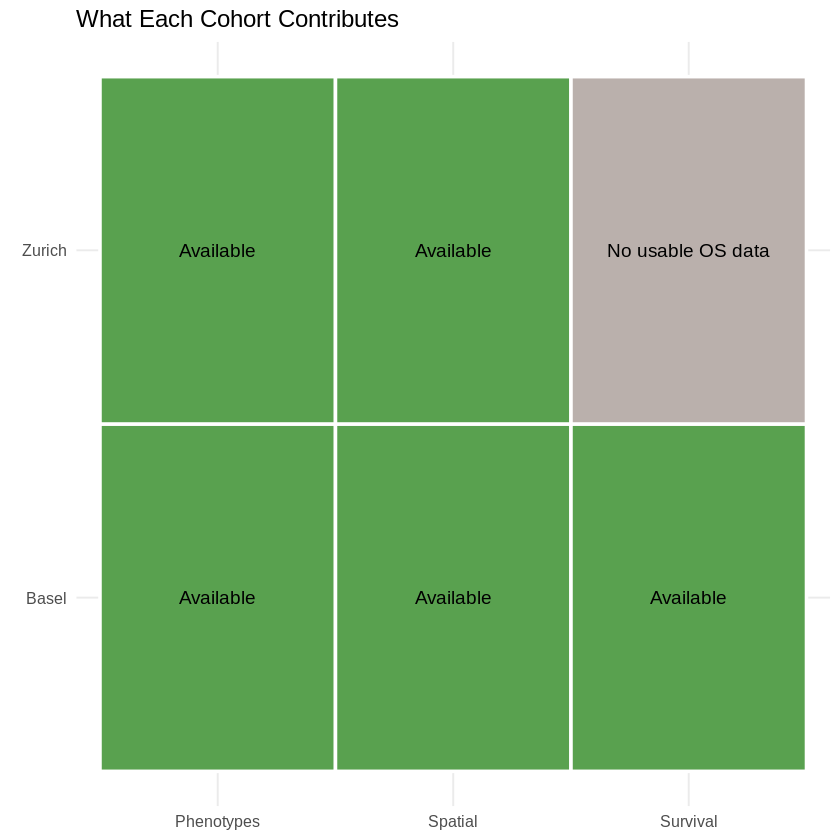

In [44]:
get_mix_df <- function(x, cohort_name) {
  if (is.null(x) || nrow(x) == 0) return(data.table())
  mix_col <- intersect(c("spatial_mixing_score", "Spatial_Mixing_Score"), names(x))[1]
  if (is.na(mix_col)) return(data.table())
  data.table(Cohort = cohort_name, core = x$core, Mixing = x[[mix_col]])
}

mix_df <- rbindlist(
  list(
    if (exists("basel_spatial_results")) get_mix_df(basel_spatial_results, "Basel") else data.table(),
    if (exists("zuri_spatial_results")) get_mix_df(zuri_spatial_results, "Zurich") else data.table()
  ),
  fill = TRUE
)

if (nrow(mix_df) > 0) {
  print(
    ggplot(mix_df, aes(x = Cohort, y = Mixing, fill = Cohort)) +
      geom_boxplot(width = 0.45, alpha = 0.75, outlier.shape = NA) +
      geom_jitter(width = 0.08, size = 2.5) +
      labs(
        title = "Spatial Mixing: Basel vs Zurich",
        x = NULL,
        y = "Mixing score"
      ) +
      theme_minimal(base_size = 12) +
      theme(legend.position = "none")
  )
}

availability <- data.table(
  Cohort = rep(c("Basel", "Zurich"), each = 3),
  Layer = rep(c("Phenotypes", "Spatial", "Survival"), times = 2),
  Status = c(
    "Available", "Available", "Available",
    "Available", "Available", "No usable OS data"
  )
)

print(
  ggplot(availability, aes(x = Layer, y = Cohort, fill = Status)) +
    geom_tile(color = "white", linewidth = 1) +
    geom_text(aes(label = Status), size = 4) +
    scale_fill_manual(values = c(
  "Available" = "#59A14F",
  "No usable OS data" = "#BAB0AC"
)) +
    labs(
      title = "What Each Cohort Contributes",
      x = NULL,
      y = NULL
    ) +
    theme_minimal(base_size = 12) +
    theme(legend.position = "none")
)